**Name:** Sneha Mahendra Kamble.<br>
**PRN:** 124B2B030<br>
**Title:** A car manufacturing company wants to predict the resale value of cars. Due to high variance and
overfitting, they want to apply regularization techniques.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt




In [ ]:
df = pd.read_csv("CarPrice_Assignment.csv")
df = df.drop(columns=["car_ID", "CarName"])


X = df.drop("price", axis=1)
y = df["price"]

categorical = X.select_dtypes(include=['object']).columns.tolist()
numerical = X.select_dtypes(include=['int64','float64']).columns.tolist()


In [ ]:
X_cat = pd.get_dummies(X[categorical], drop_first=True)
print("Shape of encoded categorical features:", X_cat.shape)


Shape of encoded categorical features: (205, 29)


In [ ]:
scaler = StandardScaler()
X_num = scaler.fit_transform(X[numerical])
X_num = pd.DataFrame(X_num, columns=numerical, index=X.index)


In [ ]:
X_processed = pd.concat([X_num, X_cat], axis=1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)


In [ ]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_train_pred = lin_model.predict(X_train)
y_test_pred = lin_model.predict(X_test)




In [ ]:

# Metrics
print("Linear Regression")
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R² :", r2_score(y_test, y_test_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Test RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Linear Regression
Train R²: 0.9476416372236126
Test R² : 0.8925566700320229
Train RMSE: 1767.0708885202273
Test RMSE : 2912.3887934772615


**Train R²** = 0.9476 → The model explains 94.8% of the variance in the training data, indicating an excellent fit.<br>
**Test R²** = 0.8926 → The model explains 89.3% of the variance in the test data, still very high, showing good generalization.

The difference between train and test R² is small (~0.055), suggesting the model is neither overfitted nor underfitted.

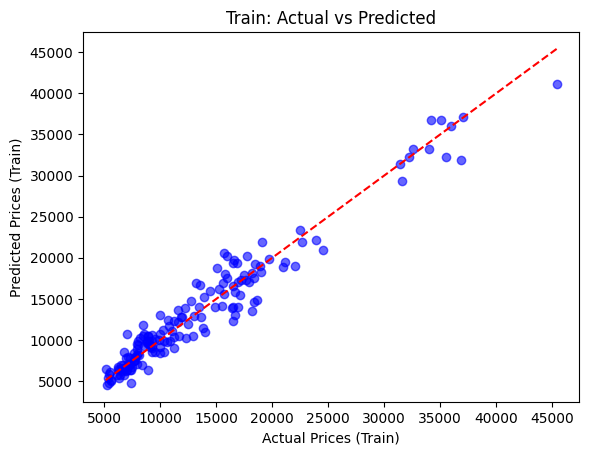

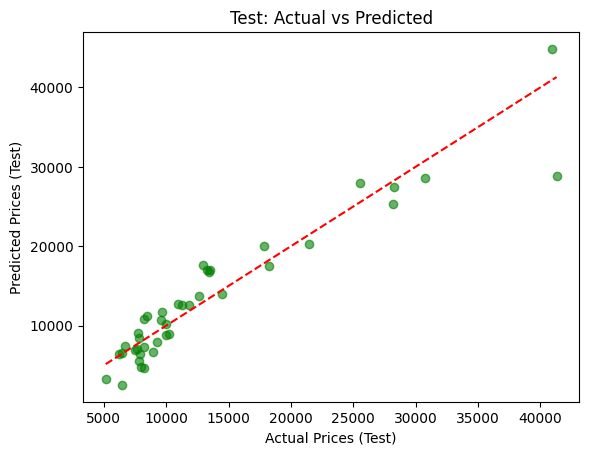

In [ ]:
# Train
plt.scatter(y_train, y_train_pred, alpha=0.6, color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.xlabel("Actual Prices (Train)")
plt.ylabel("Predicted Prices (Train)")
plt.title("Train: Actual vs Predicted")
plt.show()

# Test
plt.scatter(y_test, y_test_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices (Test)")
plt.ylabel("Predicted Prices (Test)")
plt.title("Test: Actual vs Predicted")
plt.show()


**Overfitting:** A modeling error that occurs when a model learns the training data too well, including noise, causing it to perform well on training data but poorly on unseen data.

**Underfitting:**  A modeling error that occurs when a model is too simple to capture the underlying patterns in the data, leading to poor performance on both training and test data.

In [ ]:

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train MSE: {train_mse:.2f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train R²: {train_r2:.2f}")

print(f"Test MSE: {test_mse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R²: {test_r2:.2f}")

Train MSE: 3122539.53
Train RMSE: 1767.07
Train R²: 0.95
Test MSE: 8482008.48
Test RMSE: 2912.39
Test R²: 0.89


The R² value close to 1 means the model explains 95% of the variance in training data.<br>
The model explains 89% of variance on unseen data → still strong predictive power.

**Regularization** is a technique used in machine learning to reduce overfitting by adding a penalty term to the loss function.

**Lasso Regularization:** uses L1 regularization, where a penalty equal to the sum of the absolute values of the coefficients is added to the loss function.

**Ridge:** uses L2 regularization, where a penalty equal to the sum of the squares of the coefficients is added to the loss function. I

**Elastic Net regression** is a type of linear regression that combines both L1 (Lasso) and L2 (Ridge) regularization penalties.

In [ ]:

#Lasso Regularization
lasso = Lasso(alpha=1.0, random_state=42)
lasso.fit(X_train, y_train)

y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Lasso Regression Results:")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train R2: {train_r2:.2f} ")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R2: {test_r2:.2f} ")


Lasso Regression Results:
Train RMSE: 1768.93
Train R2: 0.95 
Test RMSE: 2944.05
Test R2: 0.89 


On the training set, RMSE is 1768.93 with a very high R² of 0.95, meaning it explains most of the variance with low error.

On the test set, RMSE is 2944.05 and R² is 0.89, which is still strong and only slightly lower than training, showing good generalization.

In [ ]:

#Ridge Regularization

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)

y_train_pred = ridge.predict(X_train)
y_test_pred = ridge.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Ridge Regression Results:")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train R2: {train_r2:.2f} ")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R2: {test_r2:.2f} ")



Ridge Regression Results:
Train RMSE: 1944.22
Train R2: 0.94 
Test RMSE: 3130.55
Test R2: 0.88 


On the training set, RMSE is 1944.22 with a high R² of 0.94, showing very good fit and low error.

On the test set, RMSE rises to 3130.55 and R² drops to 0.88, still strong and close to training results.

In [ ]:

#Elastic Regularization

elastic = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)
elastic.fit(X_train, y_train)

y_train_pred = elastic.predict(X_train)
y_test_pred = elastic.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("ElasticNet Regression Results:")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train R2: {train_r2:.2f} ")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R2: {test_r2:.2f} ")



ElasticNet Regression Results:
Train RMSE: 3130.04
Train R2: 0.84 
Test RMSE: 4026.90
Test R2: 0.79 


On the training set, RMSE is 3130.04 and R² is 0.84. This means the model explains about 84% of the variance in training data, with moderate error.

On the test set, RMSE increases to 4026.90 and R² drops to 0.79. This shows the model still performs decently but slightly worse on unseen data.

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)
print("Polynomial Regression (deg=2) R²:", r2_score(y_test, poly_pred),
      "| RMSE:", np.sqrt(mean_squared_error(y_test, poly_pred)))


Polynomial Regression (deg=2) R²: -16.666755451357048 | RMSE: 37345.477788183896


Polynomial regression is a type of regression analysis where the relationship between the independent variable and the dependent variable is modeled as an nth-degree polynomial. Instead of fitting a straight line (like in linear regression), it fits a curved line to capture non-linear relationships.